In [7]:
import pandas as pd

# Load the dataset

df = pd.read_csv('All_Diets.csv')

# Handle missing data (fill missing values with mean)

numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Calculate the average macronutrient content for each diet type

avg_macros = df.groupby('Diet_type')[['Protein(g)', 'Carbs(g)', 'Fat(g)']].mean()

# Find the top 5 protein-rich recipes for each diet type

top_protein = df.sort_values('Protein(g)', ascending=False).groupby('Diet_type').head(5)

# Add new metrics (Protein-to-Carbs ratio and Carbs-to-Fat ratio)

df['Protein_to_Carbs_ratio'] = df['Protein(g)'] / df['Carbs(g)']

df['Carbs_to_Fat_ratio'] = df['Carbs(g)'] / df['Fat(g)']

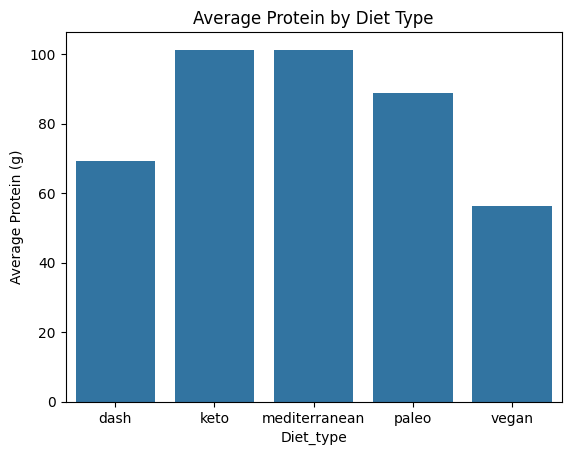

In [8]:
import seaborn as sns

import matplotlib.pyplot as plt

# Bar chart for average macronutrients

sns.barplot(x=avg_macros.index, y=avg_macros['Protein(g)'])

plt.title('Average Protein by Diet Type')

plt.ylabel('Average Protein (g)')

plt.show()

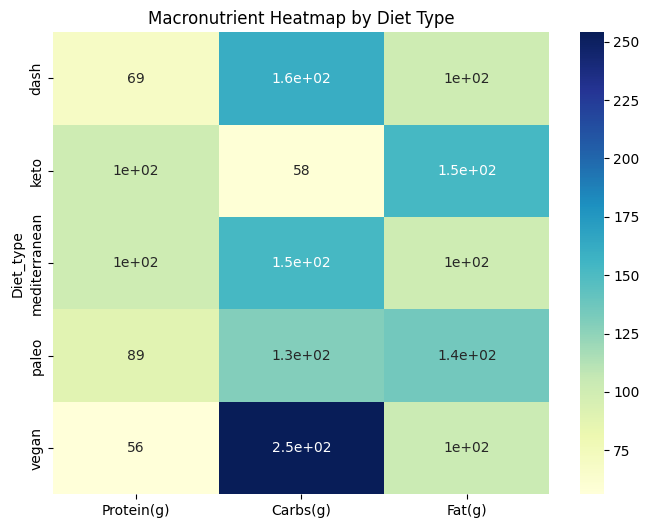

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(avg_macros, annot=True, cmap="YlGnBu")
plt.title("Macronutrient Heatmap by Diet Type")
plt.show()

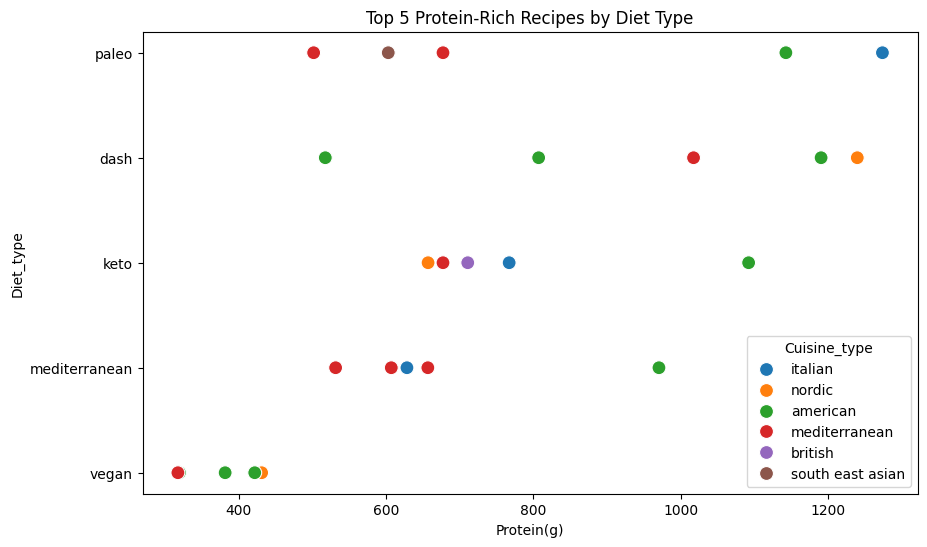

In [10]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=top_protein,
    x="Protein(g)",
    y="Diet_type",
    hue="Cuisine_type",
    s=100
)

plt.title("Top 5 Protein-Rich Recipes by Diet Type")
plt.show()